# Article Embeddings (quick & dirty)
Pulls all articles from Neo4j, embeds with `nomic-embed-text-v2-moe` via Ollama, stores back on Article nodes.

In [1]:
import ollama
from tqdm.notebook import tqdm
from db.db import get_driver

## 1. Pull articles from Neo4j

In [2]:
driver = get_driver()

with driver.session() as session:
    result = session.run("""
        MATCH (a:Article)
        WHERE a.embedding IS NULL
        RETURN a.url AS url, a.title AS title, a.full_text AS full_text
    """)
    articles = result.data()

print(f"{len(articles)} articles to embed")

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `embedding` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=3, column=17, offset=43>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 43, 'line': 3, 'column': 17}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (a:Article)\n        WHERE a.embedding IS NULL\n        RETURN a.url AS url, a.title AS title, a.full_text AS full_text\n    '


209 articles to embed


## 2. Embed

In [5]:
MODEL = "nomic-embed-text-v2-moe"

def embed(article: dict) -> list[float]:
    # Combine title + body; fall back to title only if no full_text
    text = (article["title"] or "") + "\n\n" + (article["full_text"] or "")
    text = text.strip()
    resp = ollama.embeddings(model=MODEL, prompt=text)
    return resp["embedding"]

embedded = []
for art in articles:
    try:
        vec = embed(art)
        embedded.append({"url": art["url"], "embedding": vec})
    except Exception as e:
        print(f"SKIP {art['url']}: {e}")

print(f"Embedded {len(embedded)}/{len(articles)}")

SKIP https://lematin.ma/economie/les-prix-des-viandes-rouges-en-hausse-a-casablanca-les-tomates-flambent/340486: the input length exceeds the context length (status code: 500)
SKIP https://lematin.ma/monde/guerre-au-moyen-orient-les-echanges-etats-unis-iran-menes-via-le-pakistan/340483: the input length exceeds the context length (status code: 500)
SKIP https://www.challenge.ma/chery-challenge-confort-et-autonomie-confirmes-au-volant-du-tiggo-7-pro-phev-319112/: the input length exceeds the context length (status code: 500)
SKIP https://www.challenge.ma/easyjet-inaugure-sa-base-a-marrakech-la-premiere-en-afrique-319135/: the input length exceeds the context length (status code: 500)
SKIP https://www.challenge.ma/petrole-et-gaz-hausse-des-prix-mais-aussi-des-recettes-fiscales-319069/: the input length exceeds the context length (status code: 500)
SKIP https://lematin.ma/nation/gouvernance-face-a-lincertitude-repenser-laction-publique-simpose/340387: the input length exceeds the context 

## 3. Store embeddings back in Neo4j

In [7]:
BATCH_SIZE = 50

def store_batch(session, batch):
    session.run("""
        UNWIND $rows AS row
        MATCH (a:Article {url: row.url})
        SET a.embedding = row.embedding
    """, rows=batch)

with driver.session() as session:
    for i in range(0, len(embedded), BATCH_SIZE):
        store_batch(session, embedded[i:i + BATCH_SIZE])

print("Done.")

Done.


## 4. Quick sanity check

In [8]:
with driver.session() as session:
    r = session.run("""
        MATCH (a:Article)
        RETURN
            count(a) AS total,
            count(a.embedding) AS with_embedding
    """)
    print(r.single().data())

{'total': 209, 'with_embedding': 192}


Exception ignored in: <function tqdm.__del__ at 0x000002A032B47600>
Traceback (most recent call last):
  File "c:\_PROJECTS\pfa_bvc\Pipelines\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\_PROJECTS\pfa_bvc\Pipelines\.venv\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x000002A032B47600>
Traceback (most recent call last):
  File "c:\_PROJECTS\pfa_bvc\Pipelines\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\_PROJECTS\pfa_bvc\Pipelines\.venv\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


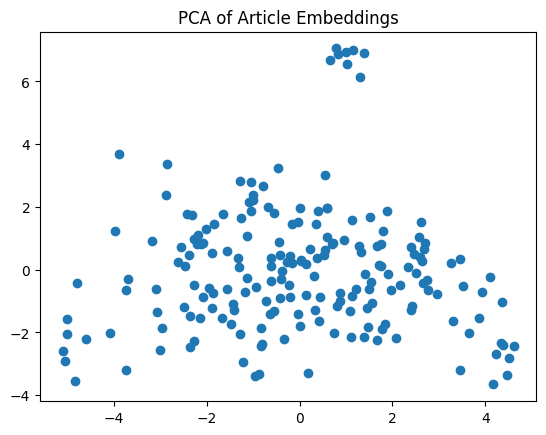

In [9]:
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

embeddings = np.array([item['embedding'] for item in embedded])
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title('PCA of Article Embeddings')
plt.show()

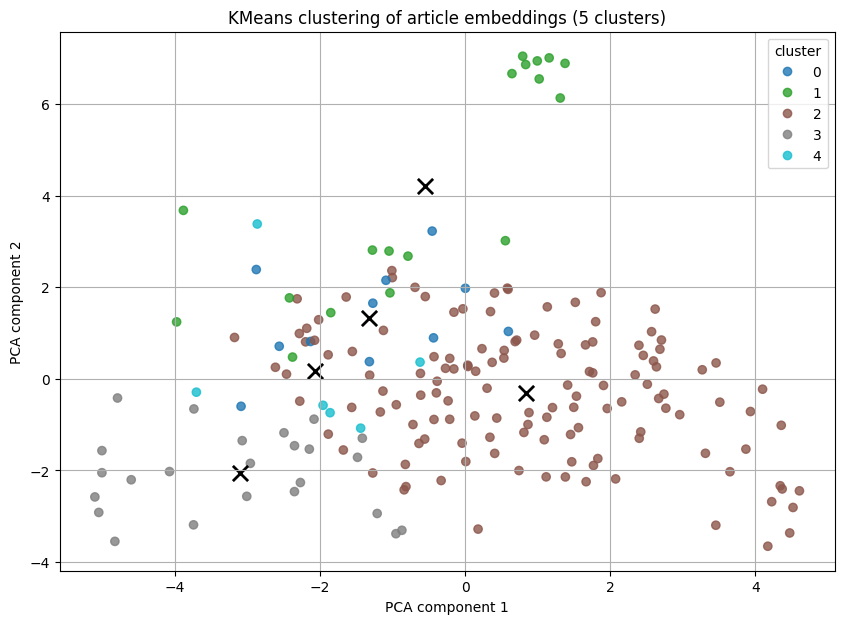

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

# project cluster centers to PCA space for plotting
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="tab10", alpha=0.8)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c="black", marker="x", s=120, linewidths=2)
plt.title(f"KMeans clustering of article embeddings ({n_clusters} clusters)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(*scatter.legend_elements(), title="cluster")
plt.grid(True)
plt.show()